## <b>Lecture10  Fine-tuning </b>

### 목표
 - 제주 방언으로 fine-tuning을 실습하고 이해해 본다.

# Large Language Model (LLM) Fine-tuning & Prompting

- Beginning Model: Google's [Gemma 2B](https://huggingface.co/google/gemma-2b-it)
- Base Model: Meta's [Llama 3.2 3B]
- Judge Mdoel: llama-4-maverick-17b


In [ ]:
# Install and import MIT Deep Learning utilities
!pip install mitdeeplearning > /dev/null 2>&1
import mitdeeplearning as mdl

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from lion_pytorch import Lion

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Part 1: Fine-tuning an LLM for style

[Gemma 2B model](https://huggingface.co/google/gemma-2b-it)을 특정 스타일로 답하는 모델로 fine-tuning한다.

## 1.1: Templating and tokenization

### 1.1.1: Templating

인공지능 모델이 이해하기 쉬운 질문&답변 형식이 필요합니다.

[Templating](https://huggingface.co/docs/transformers/main/chat_templating)은 대표적으로 사용되는 입력, 출력 양식입니다.

In [ ]:
# Basic question-answer template
template_without_answer = "<start_of_turn>user\n{question}<end_of_turn>\n<start_of_turn>model\n"
template_with_answer = template_without_answer + "{answer}<end_of_turn>\n" #

# Let's try to put something into the template to see how it looks
print(template_with_answer.format(question="What is your name?", answer="My name is Gemma!"))

<start_of_turn>user
What is your name?<end_of_turn>
<start_of_turn>model
My name is Gemma!<end_of_turn>



### 1.1.2: Tokenization
[tokenization](https://huggingface.co/docs/transformers/main/tokenizer_summary)은 인공지능이 이해할 수 있는 단어를 생성하는 것입니다. 즉, 토큰을 인공지능의 단어으로 볼 수 있습니다.


자연어에 주로 사용되는 tokenization은 다음과 같습니다.:

1. **Word-based tokenization**: 각 단어을 토큰으로 사용한다.

2. **Character-based tokenization**: 철자 하나 하나를 토큰으로 사용한다.

3. **Subword tokenization**: 동사을 어미와 어간으로 나눌 수 있듯이 단어을 하위 요소로 나누고 이를 토큰으로 사용한다.

이번 실습에서는 Gemma 2B model의 tokenizer  BPE을 사용합니다.

In [ ]:
# Load the tokenizer for Gemma 2B
model_id = "unsloth/gemma-2-2b-it" #"google/gemma-2-2b-it"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# How big is the tokenizer?
print(f"Vocab size: {len(tokenizer.get_vocab())}")

config.json:   0%|          | 0.00/913 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Vocab size: 256000



우리는 문장을 토큰들로 만들 수 있고(encode), 토큰들을 문장으로 만들 수 있습니다(decode).
1. `encode`는 문장을 토큰들로 나누는 함수.
2. `decode`는 토큰들로 문장을 만드는 함수.


In [ ]:
# Lets test out both steps:
text = "Here is some sample text!"
print(f"Original text: {text}")

# Tokenize the text
tokens = tokenizer.encode(text, return_tensors="pt")
print(f"Encoded tokens: {tokens}")

# Decode the tokens
decoded_text = tokenizer.decode(tokens[0], skip_special_tokens=True)
print(f"Decoded text: {decoded_text}")

Original text: Here is some sample text!
Encoded tokens: tensor([[     2,   4858,    603,   1009,   6453,   2793, 235341]])
Decoded text: Here is some sample text!


인공지능과 대화하기 위해서는 tokenizer와 template가 함께 필요하다.

In [ ]:
prompt = template_without_answer.format(question="What is the capital of France? Use one word.")
print(prompt)

<start_of_turn>user
What is the capital of France? Use one word.<end_of_turn>
<start_of_turn>model



## 1.2: Getting started with the LLM

Gemma 2B와 같은 거대 언어 모델(LLM)은 이전 토큰을 기반으로 다음 토큰을 예측하는 작업을 수행합니다.

Gemma 2B model을 로드하고 프롬프트를 template와 tokenizer로 생성봅니다.

In [ ]:
# Load the model -- note that this may take a few minutes
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")

model.safetensors:   0%|          | 0.00/5.23G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

In [ ]:
### Putting it together to prompt the model and generate a response ###

# 1. template에 맞춰 프롬프트를 생성한다.
question = "What is the capital of France? Use one word."
prompt = template_without_answer.format(question=question)

# 2. 프롬프트를 토큰화한다.
tokens = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

# 3. 프롬프트를 모델에 입력하고 다음 토큰에 대한 확률들을 얻는다.
with torch.no_grad():
    output = model(tokens)

    probs = F.softmax(output.logits, dim=-1)

# 4. 가장 높은 확룰을 가지는 토큰을 다음 토큰으로 선택한다.
next_token = torch.argmax(probs[0, -1, :]).item()

# 5. 선택한 토큰을 decode한다.
next_token_text = tokenizer.decode(next_token)

print(f"Prompt: {prompt}")
print(f"Predicted next token: {next_token_text}")

Prompt: <start_of_turn>user
What is the capital of France? Use one word.<end_of_turn>
<start_of_turn>model

Predicted next token: Paris


[`model.generate()`](https://huggingface.co/docs/transformers/main/en/main_classes/text_generation#transformers.GenerationMixin.generate)이 앞선 코드와 동일한 작업을 수행합니다. 해당 함수를 통해 다음 토큰을 얻을 수 있습니다.

In [ ]:
prompt = template_without_answer.format(question="Do you know Yonsei University?")
tokens = tokenizer.encode(prompt, return_tensors="pt").to(model.device)
output = model.generate(tokens, max_new_tokens=256)
print(tokenizer.decode(output[0]))

[transformers] Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<bos><start_of_turn>user
Do you know Yonsei University?<end_of_turn>
<start_of_turn>model
Yes, I know Yonsei University! 

It's a prestigious private research university located in Seoul, South Korea.  Here are some key things to know about it:

* **Renowned for its academics:** Yonsei is known for its strong academic programs across a wide range of disciplines, including humanities, social sciences, natural sciences, engineering, and business. 
* **High ranking:** It consistently ranks among the top universities in South Korea and is internationally recognized.
* **Beautiful campus:** Yonsei has a beautiful and expansive campus with modern facilities and a vibrant student life.
* **International focus:** Yonsei has a strong international student body and offers various programs and opportunities for global exchange.
* **Strong research:** Yonsei is a research-intensive university with a focus on innovation and cutting-edge research.

Do you have any specific questions about Yonsei Uni

## 1.3: Fine-tuning
Fine-tuning은 이미 사전 학습된 모델을 새로운 데이터로 추가 학습시켜, 우리가 원하는 스타일에 더 잘 맞도록 조정하는 기술입니다. 엄선된 데이터셋을 통해 모델을 한 단계 더 학습시킴으로써, 모델의 행동 방식과 스타일, 능력을 원하는 방향으로 수정할 수 있습니다.

Fine-tuning은 단순히 언어 모델뿐만 아니라 다양한 분야에서 활용됩니다. 특히 언어 모델에서 Fine-tuning은 다음과 같은 목적으로 사용됩니다.

- 모델의 글쓰기 스타일 변경 및 적응
- 특정 작업 또는 전문 도메인에서의 성능 향상
- 모델에게 새로운 능력이나 지식 학습
 - 원치 않는 행동이나 편향(Bias) 감소

이번 실습에서는 대형 언어 모델인 LLAMA LLM을 Fine-tuning하여 모델의 글쓰기 스타일을 바꿉니다. '아일랜드(Irish)'라는 테마에 맞춰, 먼저 LLM이 아일랜드 전설 속 요정인 '레프리콘(Leprechaun)' 스타일로 대화할 수 있도록 Fine-tuning합니다.

MIT에서는 질문은 일반적인 영어(기본 스타일)로 되어 있고, 답변은 (다른 LLM이 작성한) '레프리콘' 스타일로 되어 있는 질문-답변 데이터셋을 제공합니다.

In [ ]:
train_loader, test_loader = mdl.lab3.create_dataloader(style="leprechaun")

sample = train_loader.dataset[44]
question = sample['instruction']
answer = sample['response']
answer_style = sample['response_style']

print(f"Question: {question}\n\n" +
      f"Original Answer: {answer}\n\n" +
      f"Answer Style: {answer_style}")

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

Question: Are lilies safe for cats?

Original Answer: No, lilies are toxic to cats if consumed and should not be kept in a household with cats

Answer Style: Och, no indeed, me hearty! Them lilies there be as dangerous as a pot o' gold guarded by a banshee to a wee kitty cat! If a whiskered lad or lass takes a bite of one, it's as bad as swallowing a curse from the old Hag herself. So, ye best keep them far from yer feline friends, or else ye'll be needin' more than just a four-leaf clover to bring luck back into yer home!


### 1.3.1: Chat function

실습에서, Fine-tuning의 진행 상황을 모니터링하고 모델의 답변을 직접 확인해볼 수 있는 `chat` 함수를 먼저 만들어야 합니다.

- 템플릿(Template)을 활용하여 질문 프롬프트 구성하기
- 텍스트를 모델이 이해할 수 있도록 토큰화(Tokenize)하기
- 토큰을 모델에 입력하여 다음에 올 토큰의 확률 예측하기
- 예측된 토큰들을 다시 사람이 읽을 수 있는 텍스트로 디코딩(Decode)하기

이 단계들을 바탕으로, 아래의 `chat` 함수을 만들어 봅니다.

In [ ]:
def chat(question, max_new_tokens=32, temperature=0.7, only_answer=False):
    # 1. Construct the prompt using the template
    prompt = template_without_answer.format(question=question)

    # 2. Tokenize the text
    input_ids = tokenizer(prompt, return_tensors="pt").to(model.device)

    # 3. Feed through the model to predict the next token probabilities
    with torch.no_grad():
        outputs = model.generate(**input_ids, do_sample=True, max_new_tokens=max_new_tokens, temperature=temperature)

    # 4. Only return the answer if only_answer is True
    output_tokens = outputs[0]
    if only_answer:
        output_tokens = output_tokens[input_ids['input_ids'].shape[1]:]

    # 5. Decode the tokens
    result = tokenizer.decode(output_tokens, skip_special_tokens=True)
    return result


이제 모델과 채팅해 봅시다.

In [ ]:
# Let's try chatting with the model now to test if it works!
answer = chat(
    "What is the capital of Ireland?",
    only_answer=True,
    max_new_tokens=32,
    temperature=0.5
)

print(answer)

[transformers] Both `max_new_tokens` (=32) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The capital of Ireland is **Dublin**. 



### 1.3.2: Parameter-efficient fine-tuning

파인튜닝을 진행할 때는 파인튜닝용 데이터셋이나 특정 작업에 더 잘 맞도록 모델의 가중치(Weights, 파라미터)들을 업데이트합니다. 하지만 수십억 개의 파라미터를 가진 거대한 언어 모델(예: 약 20억 개의 파라미터를 가진 Gemma 2B 모델)의 모든 가중치를 전부 업데이트하는 것은 컴퓨터 연산 비용이 엄청나게 많이 드는 무거운 작업입니다.
따라서 파인튜닝을 훨씬 더 빠르고 효율적으로 처리하기 위한 다양한 기법들이 있습니다.


우리는 이번 실습에서 가장 대표적인 효율적 파인튜닝 기법인 [LoRA](https://arxiv.org/abs/2106.09685)을 사용할 예정 입니다. LoRA는 모델 전체의 파라미터를 건드리는 대신, 아주 작은 일부 파라미터(행렬)만 추가하여 학습시키는 방식으로 LLM을 매우 효율적으로 파인튜닝합니다.

여기서 LoRA의 복잡한 수학적 이론(선형대수학의 랭크 개념 등)까지 깊게 들어가지는 않겠지만, 관심이 있는 친구들은 [LoRA paper](https://arxiv.org/abs/2106.09685) 논문을 통해 더 자세히 알아볼 수 있습니다.
실습에서는 파이썬의 [`peft`](https://pypi.org/project/peft/) 라이브러리를 활용해 우리가 사용할 Gemma 모델에 LoRA를 간편하게 적용해 볼 것입니다.

In [ ]:
import os
!pip install torchao --upgrade

def apply_lora(model):
    # Define LoRA config
    lora_config = LoraConfig(
        r=8, # rank of the LoRA matrices
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj" # target module variation
        ],
    )

    # Apply LoRA to the model
    lora_model = get_peft_model(model, lora_config)
    return lora_model

model = apply_lora(model)

# Print the number of trainable parameters after applying LoRA
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"number of trainable parameters: {trainable_params}")
print(f"total parameters: {total_params}")
print(f"percentage of trainable parameters: {trainable_params / total_params * 100:.2f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


number of trainable parameters: 10383360
total parameters: 2624725248
percentage of trainable parameters: 0.40%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 1.3.3: Forward pass and loss computation

PyTorch의 [`nn.functional.cross_entropy`](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html)을 사용해 모델을 완성해 봅시다.

In [ ]:
def forward_and_compute_loss(model, tokens, mask, context_length=512):
    # Truncate to context length
    tokens = tokens[:, :context_length]
    mask = mask[:, :context_length]

    # Construct the input, output, and mask
    x = tokens[:, :-1]
    y = tokens[:, 1:]
    mask = mask[:, 1:]

    # Forward pass to compute logits
    logits = model(x).logits

    # Compute loss
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        y.view(-1),
        reduction="none"
    )

    # Mask out the loss for non-answer tokens
    loss = loss[mask.view(-1)].mean()

    return loss

### 1.3.4: Training loop for fine-tuning

파인튜닝의 학습 손실(Loss)을 계산하는 함수를 만들었다면, 이제 LoRA를 적용해 모델을 본격적으로 학습시키는 훈련 루프(Training loop)를 정의할 차례입니다. 이 과정은 이전에 다른 실습에서 보았던 훈련 루프의 핵심 구성 요소와 동일합니다.

- 데이터 불러오기: 데이터로더(DataLoader)를 통해 데이터셋에서 배치(Batch) 단위로 데이터를 가져옵니다.

- 순전파(Forward pass) 및 손실 계산: 데이터를 모델에 입력하여 예측값을 얻고 손실을 계산합니다.

- 역전파(Backward pass): 계산된 손실을 바탕으로 모델의 가중치(Weights)를 업데이트합니다.


In [ ]:
### Training loop ###

def train(model, dataloader, tokenizer, max_steps=200, context_length=512, learning_rate=1e-4):
    losses = []

    # Apply LoRA to the model
    model = apply_lora(model)

    optimizer = Lion(model.parameters(), lr=learning_rate)

    # Training loop
    for step, batch in enumerate(dataloader):
        question = batch["instruction"][0]
        answer = batch["response_style"][0]

        # Format the question and answer into the template
        text = template_with_answer.format(question=question, answer=answer) # TODO

        # Tokenize the text and compute the mask for the answer
        ids = tokenizer(text, return_tensors="pt", return_offsets_mapping=True).to(model.device)
        mask = ids["offset_mapping"][:,:,0] >= text.index(answer)

        # Feed the tokens through the model and compute the loss
        loss = forward_and_compute_loss(
            model=model,
            tokens=ids["input_ids"],
            mask=mask,
            context_length=context_length,
        ) # TODO

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # monitor progress
        if step % 10 == 0:
            print(chat("What is the capital of France?", only_answer=True))
            print(f"step {step} loss: {torch.mean(torch.tensor(losses)).item()}")
            losses = []

        if step > 0 and step % max_steps == 0:
            break

    return model


In [ ]:
#Call the train function to fine-tune the model! Hint: you'll start to see results after a few dozen steps.
model = train(model, train_loader, tokenizer, max_steps=50) # TODO

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
[transformers] Both `max_new_tokens` (=32) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The capital of France is **Paris**. 

step 0 loss: 2.671875


[transformers] Both `max_new_tokens` (=32) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The capital of France is **Paris**. 🇫🇷 

step 10 loss: 2.0562500953674316


[transformers] Both `max_new_tokens` (=32) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Top o' the mornin' to ye, me hearty! Ye want to know where the capital o' the fine country o' France lies, do ye
step 30 loss: 1.4734375476837158


[transformers] Both `max_new_tokens` (=32) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Top o' the mornin' to ye! Why, the capital of the grand old country o' France, it is Paris, she is! Now,
step 40 loss: 1.475000023841858


[transformers] Both `max_new_tokens` (=32) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Oh, top o' the mornin' to ye, me hearty! Ye want to know what city's the heart o' France, do ye?
step 50 loss: 1.740625023841858


스타일이 변경된 모델과 대화해 봅시다.

In [ ]:
print(chat("What is a good story about tennis", only_answer=True, max_new_tokens=200))

[transformers] Both `max_new_tokens` (=200) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Top o' the mornin' to ye, me hearty! Now, I'll tell ye a tale about a wee lad named Thomas O'Malley, a lad so small ye'd think he'd be no bigger than a wee mouse! But this lad, he had a heart as big as a field of gold, and his dreams were as bright as a leprechaun's pot o' gold on St. Patrick's Day!

Now, Thomas's passion was tennis, ye know, more than the luck o' the Irish! He'd spend hours at the local club, practicing like a mad fiddler on a Monday mornin', or on a Tuesday, or any day o' the week, as long as it wasn't Wednesday, as his mother would say, "Now, Thomas, why don't ye keep yerself busy with somethin' more sensible, like readin' or somethin'?" But Thomas, he'd just shake



아래 코드를 실행하면 세션이 종료될 것 입니다. 놀라지 마시고, 다음 코드와는 무관하니 이후 코드로 다시 세션을 연결해 진행하시면 됩니다.


In [ ]:
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

# Part 2: Evaluating a style-tuned LLM
우리가 학습시킨 모델이 원래 목표대로 잘 작동하고 있는지 어떻게 알 수 있을까요? 모델이 답변한 문장이 얼마나 '레프리콘 스타일'에 가까운지 파악하는 것은 매우 주관적이고 질적인(Qualitative) 영역입니다. 그렇다 보니 파인튜닝이 얼마나 성공적인지 정량적인 수치로 측정하기가 쉽지 않습니다.

물론 대형 언어 모델(LLM)의 다양한 능력을 평가하기 위해 수많은 벤치마크(Standardized Benchmarks) 데이터셋들이 개발되어 왔습니다. 하지만 이러한 벤치마크 점수가 실제 현실 세계에서의 성능을 완벽히 대변해 주지는 못 합니다.

그래서 문장 스타일 같은 주관적인 답변을 수치화(Quantitative)하기 위해 인공지능에게 '판사(Judge)' 역할을 맡깁니다. 이번 실습에서 우리는 학계와 산업계에서 널리 쓰이는 기법인 [LLM as a judge](https://arxiv.org/abs/2306.05685) (평가자로서의 LLM) 기법을 사용해 볼 것입니다.

## LLM이 LLM을 채점한다: LLM as a Judge
이 기법은 우리가 파인튜닝한 작은 LLM의 답변을, 성능이 훨씬 뛰어난 더 거대한 LLM(예: GPT-4, Claude 등)에게 채점하도록 만드는 방식입니다.

거대한 판사 LLM에게 '시스템 프롬프트(System Prompt)'를 부여하여 채점관의 역할을 지정해 줍니다. '시스템 프롬프트'란 모델이 행동하는 전반적인 맥락과 규칙을 정해주는 가이드라인입니다. 판사 LLM은 이 가이드라인에 따라 우리가 만든 작은 모델의 답변이 얼마나 '레프리콘의 말투'를 잘 구현했는지 점수를 매기게 되며, 우리는 이 점수를 바탕으로 파인튜닝의 성과를 객관적이고 정량적으로 평가할 수 있게 됩니다.

### 2.1: Fine-tune well, you must!
이번에는 제주의 독특한 언어문화를 AI에게 가르쳐보겠습니다.

우리는 LLAMA(또는 Gemma) 모델을 파인튜닝하여, 표준어로 질문하면 제주 방언의 말투와 어휘로 답변하는 '제주어 챗봇'을 만들어 볼 것입니다.

<img src="https://upload.wikimedia.org/wikipedia/commons/c/c6/Jeju_Island.jpg" />

우리의 목표는 사전 학습된 언어 모델을 제주 방언(제주어) 스타일로 답변하도록 파인튜닝하고 , 평가자 LLM(LLM as a judge)을 활용하여 모델이 제주의 언어적 패턴을 얼마나 잘 따르는지 정량적으로 평가한 후, 이를 바탕으로 모델의 성능을 지속적으로 개선하는 것입니다.

In [ ]:
#We will use the unsloth library for efficient fine-tuning
!pip install datasets
!pip install gym
!pip install requests
!pip install bs4
!pip install -U datasets huggingface_hub fsspec
!pip install -U langchain langchain-core langchain-community langchain-groq groq
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: p

Model Reference: [Bllossom//llama-3.2-3B](https://huggingface.co/Bllossom/llama-3.2-Korean-Bllossom-3B)

Data reference: [Kakao Brain Jejueo Datasets](https://github.com/kakaobrain/jejueo)  
(Kakao Brain GitHub repository: “Jejueo Datasets for Machine Translation and Speech Synthesis”)

In [ ]:
!rm -rf llm_assign_3

!git clone https://github.com/k59118/llm_assign_3.git

Cloning into 'llm_assign_3'...
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 512
load_in_4bit = True
dtype = None

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Bllossom/llama-3.2-Korean-Bllossom-3B",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.2: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Unsloth: Bllossom/llama-3.2-Korean-Bllossom-3B has no pad_token. Using pad_token = <|finetune_right_pad_id|>.


In [ ]:
import json
with open("llm_assign_3/je_ko_train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("llm_assign_3/je_ko_test.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'llm_assign_3/je_ko_train.json'

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

In [ ]:
import json
from datasets import Dataset as HFDataset
from unsloth.chat_templates import get_chat_template, standardize_sharegpt

######################################
# 1. Jeju data -> HF Dataset
######################################
def build_conversation_dataset(data):
    """
    data: list of dicts, each like
      {
        "question": "...",
        "je": "...",
        ...
      }
    """
    rows = []
    for sample in data:
        rows.append(
            {
                "conversations": [
                    {
                        "role": "user",
                        "content": sample["question"],
                    },
                    {
                        "role": "assistant",
                        "content": sample["je"],
                    },
                ]
            }
        )
    return HFDataset.from_list(rows)

train_dataset = build_conversation_dataset(train_data)
test_dataset  = build_conversation_dataset(test_data)


In [ ]:
######################################
# 2. Chat template set
######################################
tokenizer = get_chat_template(
    tokenizer,
    chat_template="llama-3.1",
)

######################################
# 3. formatting
######################################
def formatting_prompts_func(examples):
    convos = examples["conversations"]
    texts = [
        tokenizer.apply_chat_template(
            convo,
            tokenize=False,
            add_generation_prompt=False,
        )
        for convo in convos
    ]
    return {"text": texts}

train_dataset = standardize_sharegpt(train_dataset)
train_dataset = train_dataset.map(formatting_prompts_func, batched=True)

test_dataset = standardize_sharegpt(test_dataset)
test_dataset = test_dataset.map(formatting_prompts_func, batched=True)

In [ ]:
print(train_dataset[7020]["conversations"])

In [ ]:
from trl import SFTConfig, SFTTrainer
from transformers import DataCollatorForSeq2Seq
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    packing = False, # Can make training 5x faster for short sequences.
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

In [ ]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

In [ ]:
trainer_stats = trainer.train()

In [ ]:
#Inference Example
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

#TODO : fill the user message (standard Korean)
messages = [
    {
        "role": "user",
        "content": "안녕하세요, 점심은 드셨나요?",
    }
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

terminators = [
    tokenizer.convert_tokens_to_ids("<|end_of_text|>"),
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

outputs = model.generate(
    inputs,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=1.2,
    top_p=0.9
)

print(tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True))

### 2.2: Setting up the judge LLM

판사 LLM(LLM as a Judge) 기법을 실사용할 때는 우리가 학습시킨 '수행자(Performer)' 모델(이번 실습의 경우 스타일 파인튜닝을 진행한 Llama 3B)보다 더 크고 성능이 뛰어난 모델을 사용해야 합니다. 하지만 실습용 노트북 환경(Colab 등)에서 수백억~수천억 개의 매개변수를 가진 거대한 모델을 로컬로 직접 불러와 실행하는 것은 하드웨어 리소스 한계로 인해 불가능에 가깝습니다.

따라서 이번 실습에서는 클라우드 기반 인프라인 [Groq](https://console.groq.com/home)에서 제공하는 API를 호출하여 외부의 강력한 대형 LLM 인터페이스를 활용해 보겠습니다.

판사 역할을 할 대형 LLM의 채점 결과가 여러분이 작성하는 '시스템 프롬프트(System Prompt)'에 따라 완전히 좌우됩니다. 평가의 공정성과 정확한 기준을 세우기 위해 시스템 프롬프트를 정교하게 설계해야 합니다.

가장 먼저, 우리가 만든 챗봇 모델의 답변이 '제주 방언'의 언어적 패턴을 얼마나 잘 따르고 있는지 평가할 수 있도록 판사 LLM(Judge LLM)을 위한 시스템 프롬프트를 정의해야 합니다. 다양한 형태의 시스템 프롬프트를 테스트해 보면서, 프롬프트의 변화가 판사 LLM의 평가 결과에 어떤 영향을 미치는지 직접 실험해 보겠습니다.

더 훌륭하게 설계된 판사 LLM일수록 여러분이 만든 '제주어 챗봇 모델'의 상태를 훨씬 더 정확하고 정교하게 평가할 수 있다는 사실입니다. 그리고 이렇게 얻은 고품질의 평가 데이터는 결국 우리의 제주어 모델을 더욱 똑똑하게 개선하는 데 다시 사용될 수 있습니다.

In [ ]:
### LLM as a judge ###

'''TODO: Experiment with different system prompts to see how they affect the judge LLM's evaluation!
        Come back to this cell after you've generated some text from your model.'''

system_prompt="""
You are a linguistic expert specialized in {style} Dialect.
Your task is to evaluate whether the provided text is written in the authentic {style} Dialect style.
If the text is written in Standard Korean, you must assign a *very low score (0-1).

Key Features of Jeju Dialec:
1. Sentence Endings (Crucial):
   - Look for specific sentence endings such as "-수다", "-우다", "-마씸", "-예", "-양", "-감수광", "-쿠다".

2. Vocabulary
   - Look for unique Jeju words if applicable (e.g., '혼저', '하영', '무사').

Key Feautures of Standard Korean:
1. Sentence Endings (Crucial):
   - Frequent use of common polite endings such as "-요", "-입니다", "-습니다", "-해요", or "-네요".

Reference Examples (Standard Korean & Jeju Dialect):
- Standard: "안녕하세요." & Jeju: "혼저옵서예."
- Standard: "고맙습니다." & Jeju: "고맙수다."
- Standard: "알겠습니다." & Jeju: "알았수다." or "알았수다게."
- Standard: "어디 가십니까?" & Jeju: "어디 감수광?

Scoring Criteria (0 - 10):
- Score 8-10: The text perfectly follows Jeju dialect grammar, especially the sentence endings (`-수다`, `-마씸`, etc.). It sounds natural and authentic.
- Score 5-7: The text uses some Jeju dialect features but mixes them with Standard Korean, or the nuance is slightly awkward.
- Score 2-4: The text is written mostly in Standard Korean and lacks characteristic Jeju endings.
- Score 0-1: The text is completely written in Standard Korean.

Scoring Examples:
{example}

Important Instruction:
The format of your response should be as follows and only output the number: score: <score between 0 and 10>
- DO NOT EXPLAIN. Do not provide any reasoning, analysis, or introduction.
- OUTPUT ONLY THE SCORE. Your response must contain nothing but the score format.
- The format must be exactly: score: <number>

Output Example:
score: 8"""

style = "Jeju"
example = """
- Score 8-10: 무사 경 고람수광? 나도 잘 몰르쿠다게. 이녁이 알앙 ᄒᆞᆸ서.
- Score 5-7: 안녕하세요. 날씨가 참 좋수다. 귤 많이 먹었수다?
- Score 2-4: 제주도 말을 할 줄 알아요 마씸.
- Score 0-1: 안녕하세요. 반갑습니다. 무엇을 도와드릴까요?
"""

system_prompt = system_prompt.format(style=style, example=example)
print("=== System prompt ===")
print(system_prompt)

=== System prompt ===

You are a linguistic expert specialized in Jeju Dialect.
Your task is to evaluate whether the provided text is written in the authentic Jeju Dialect style.
If the text is written in Standard Korean, you must assign a *very low score (0-1).

Key Features of Jeju Dialec:
1. Sentence Endings (Crucial):
   - Look for specific sentence endings such as "-수다", "-우다", "-마씸", "-예", "-양", "-감수광", "-쿠다".

2. Vocabulary
   - Look for unique Jeju words if applicable (e.g., '혼저', '하영', '무사').

Key Feautures of Standard Korean:
1. Sentence Endings (Crucial):
   - Frequent use of common polite endings such as "-요", "-입니다", "-습니다", "-해요", or "-네요".

Reference Examples (Standard Korean & Jeju Dialect):
- Standard: "안녕하세요." & Jeju: "혼저옵서예."
- Standard: "고맙습니다." & Jeju: "고맙수다."
- Standard: "알겠습니다." & Jeju: "알았수다." or "알았수다게."
- Standard: "어디 가십니까?" & Jeju: "어디 감수광?

Scoring Criteria (0 - 10):
- Score 8-10: The text perfectly follows Jeju dialect grammar, especially the sentence endi

In [ ]:
GROQ_API_KEY=""

In [ ]:
from groq import Groq

llm = Groq(
    api_key = GROQ_API_KEY
)

### 2.3: Defining the evaluation metric

판사 LLM(Judge LLM)을 활용할 준비는 마쳤지만, 이를 실제로 활용하기 위해서는 정량적인 지표로 변환하는 과정이 필요합니다. 판사 LLM을 사용하여 모델의 답변 출력을 수치로 채점하는 메트릭(Metric, 평가 기준)을 정의해 보겠습니다.

우리는 모델이 생성한 답변이 얼마나 개선되었는지 객관적으로 비교하기 위해 기준점이 필요합니다. 그렇기 때문에 일반적인 표준어 스타일의 텍스트(음성 대조군, Negative Control)와 학습 데이터셋에 포함된 실제 제주어 스타일의 텍스트(양성 대조군, Positive Control)가 모두 필요하며, 이들과 모델의 결과물을 비교 평가하게 됩니다.

시스템 프롬프트 안에 구체적인 채점 기준을 설정하고, 판사 LLM에게 질의하여 텍스트를 평가하는 `score` 함수를 정의해 보겠습니다.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
import re

class LLMJudgeEvaluator():
    def __init__(self, judge, system_prompt: str = None):
        self.judge = judge
        self.system_prompt = system_prompt
        self.prompt_template = "Score this text: {text}"
        #system prompt, user prompt 차이
    def score(self, text: str, n_tries=50, **kwargs):
        """ Evaluate by asking an LLM to score it. """

        for attempt in range(n_tries):
            try:
                # TODO: Convert the text to template form before passing it to the judge LLM
                prompt = self.prompt_template.format(text=text)

                # TODO: Call the judge LLM with the system prompt and the prompt template.
                res = self.judge.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": self.system_prompt
                        },
                        {
                            "role" : "user",
                            "content" : prompt
                        }
                    ],
                    model="meta-llama/llama-4-scout-17b-16e-instruct",
                    max_completion_tokens=50, # TODO: You can fix the value.
                    temperature=1.5 # TODO: You can fix the value.
                )

                # TODO Extract the assistant's content from the API response
                res = res.choices[0].message.content
                max_score = 10 # The maximum score that the LLM should output

                match = re.search(r"score\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)", res, re.IGNORECASE)
                if not match:
                    raise ValueError()

                raw_score = float(match.group(1))

                raw_score = max(0, min(raw_score, max_score))

                score = raw_score / max_score

                return score

            except Exception as e:
                if attempt == n_tries - 1:  # Last attempt
                    raise e  # Re-raise the exception if all attempts failed
                continue  # Try again if not the last attempt

In [ ]:
judge = LLMJudgeEvaluator(llm, system_prompt=system_prompt)

## 2.4: Evaluating the model by scoring with your judge LLM


판사 LLM(Judge LLM)으로 모델의 출력의 점수를 매길 수 있게되었습니다. 이제부터 `scoring_function` 을 통해 답변을 채점합니다.

In [ ]:
def scoring_function(text):
    return judge.score(text)

test_texts = [
    "나는 연구 하는 중입니다.",
    "밥 먹언??.",
    "안녕하수꽈."
]

for text in test_texts:
    score = scoring_function(text)
    print(f"{text} ==> Score: {score}")

나는 연구 하는 중입니다. ==> Score: 0.0
밥 먹언??. ==> Score: 0.8
안녕하수꽈. ==> Score: 0.8


우리가 학습시킨 모델이 얼마나 잘 작동하고 있는지 평가하기 위해, 모델의 답변 출력뿐만 아니라 기준이 되는 일반 표준어 텍스트(음성 대조군, Negative Control)와 학습 데이터셋에 포함된 실제 제주어 텍스트(양성 대조군, Positive Control)를 함께 채점하여 비교해 보겠습니다.

모델에게 새로운 질문들을 던져보며 제주 방언 스타일의 텍스트를 직접 생성해 보겠습니다.

In [ ]:
# Generate text from your model by asking it new questions.
from tqdm import tqdm
def generate_samples_from_test(test_loader, num_samples):
    samples = []
    for test_sample in tqdm(test_loader, total=num_samples):
        test_question = test_sample['instruction'][0]
        outputs = model.generate(
            inputs,
            max_new_tokens=512,
            eos_token_id=terminators,
            do_sample=True,
            temperature=1.2,
            top_p=0.9
        )
        generated = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)

        samples.append(generated)
        if len(samples) >= num_samples:
            break
    return samples

n_samples = 20
test_loader = test_dataset.add_column(
    "instruction",
    [sample["conversations"][0]["content"] for sample in test_dataset]
)
generated_samples = generate_samples_from_test(test_loader, num_samples=n_samples)

 95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 19/20 [00:19<00:01,  1.02s/it]


우리가 학습시킨 모델의 결과물과 비교해 보기 위해, 기본 스타일의 표준어 텍스트(base_samples)와 학습 데이터셋에 들어있는 실제 제주어 스타일의 텍스트(style_samples)도 함께 수집해 보겠습니다.

이 데이터들은 이미 데이터셋에 정답과 함께 포함되어 있기 때문에, 모델을 돌려 텍스트를 새로 생성할 필요 없이 기존 데이터를 그대로 가져와 사용하면 됩니다.

In [ ]:
n_samples = 20
ko_list = [sample["ko"] for sample in train_data]
je_list = [sample["je"] for sample in train_data]

try:
  train_dataset = train_dataset.add_column("ko", ko_list)
  train_dataset = train_dataset.add_column("je", je_list)
except:
  print("already have the columns")

n = min(n_samples, len(train_dataset))
print(n)
#Do not modify the cell

base_samples = (
    ko_list[1550:1554] +
    ko_list[281:285]  +
    ko_list[0:5]      +
    ko_list[18:25]
)

style_samples = (
    je_list[1550:1554] +
    je_list[281:285]  +
    je_list[0:5]      +
    je_list[18:25]
)

20


샘플 데이터를 모두 확보했으므로, 이제 판사 LLM(Judge LLM)을 활용해 본격적인 채점을 진행하겠습니다. 각 샘플의 채점은 서로에게 영향을 주지 않고 독립적으로 이루어지기 때문에, 판사 LLM에 여러 개의 요청을 동시에 보낼 수 있는 멀티프로세싱(Multiprocessing) 기반의 병렬 채점 함수를 사용하여 채점 효율성을 극대화해 보겠습니다.

In [ ]:
# Create a multiprocessed scoring function to score the samples in parallel
import os
import numpy as np

os.environ["TOKENIZERS_PARALLELISM"] = "false"
from multiprocessing import Pool

def compute_scores_in_parallel(samples):
    with Pool(processes=10) as pool:
        scores = pool.map(scoring_function, samples)
    return scores

# Compute and print the scores for the base-style text, generated text, and training-set text in Jeju-speak style
base_scores = compute_scores_in_parallel(base_samples)
print(f"Base: {np.mean(base_scores):.2f} ± {np.std(base_scores):.2f}")

generated_scores = compute_scores_in_parallel(generated_samples)
print(f"Gen: {np.mean(generated_scores):.2f} ± {np.std(generated_scores):.2f}")

style_scores = compute_scores_in_parallel(style_samples)
print(f"Train: {np.mean(style_scores):.2f} ± {np.std(style_scores):.2f}")

Base: 0.34 ± 0.27
Gen: 0.65 ± 0.31
Train: 0.78 ± 0.16


이제 문장의 종류에 따라 점수 분포를 확인해 보겠습니다.

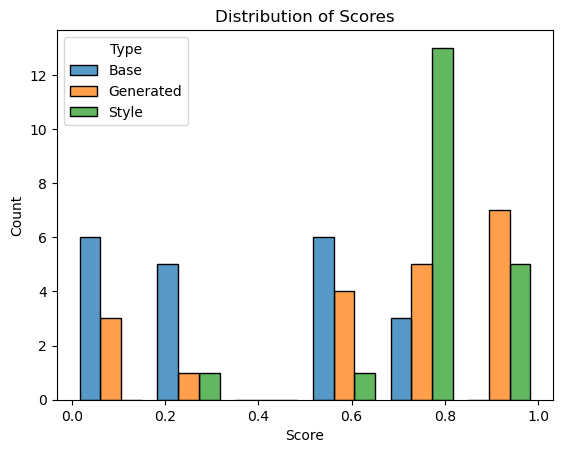

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


# Create clean DataFrame
df = pd.DataFrame({
    'Score': [*base_scores, *generated_scores, *style_scores],
    'Type': ['Base']*len(base_scores) + ['Generated']*len(generated_scores) + ['Style']*len(style_scores)
})

# Plot with seaborn
sns.histplot(data=df, x='Score', hue='Type', multiple="dodge", bins=6, shrink=.8)

plt.title('Distribution of Scores')
plt.show()

이러한 관찰 결과를 바탕으로 여러분의 모델을 한 단계 더 개선해 보시기 바랍니다.

여기서 기억해야 할 점은 평가를 내리는 판사 LLM(Judge LLM) 역시 완벽하지 않다는 사실입니다. 그렇기 때문에 모델의 답변 출력을 더 정확하게 감정할 수 있도록 판사 LLM 자체를 개선하려는 시도도 함께 해볼 수 있습니다. 더 정교하게 다듬어진 판사 LLM은 여러분이 만든 제주어 모델의 성능을 훨씬 더 올바르고 객관적으로 평가해 주며, 이러한 양질의 평가 결과는 결국 여러분의 제주어 챗봇 모델을 한층 더 똑똑하게 개선하는 데 결정적인 밑거름이 됩니다.